# DeepGBoost — Benchmark

Compares **DeepGBoost** against a standard suite of ensemble methods across
three tasks:

| Task | Dataset | n_samples | n_features |
|---|---|---|---|
| Regression | California Housing | 20 640 | 8 |
| Binary classification | Breast Cancer | 569 | 30 |
| Multiclass classification | Iris | 150 | 4 |

**Competitors**
- `sklearn` GradientBoostingRegressor / Classifier
- `sklearn` RandomForestRegressor / Classifier
- `sklearn` AdaBoostRegressor / Classifier
- `xgboost` XGBRegressor / XGBClassifier  *(skipped if not installed)*
- `lightgbm` LGBMRegressor / LGBMClassifier  *(skipped if not installed)*

Results are written to **`results.md`** in the same folder.

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from sklearn.datasets import fetch_california_housing, load_breast_cancer, load_iris
from sklearn.model_selection import cross_validate, StratifiedKFold, KFold
from sklearn.ensemble import (
    GradientBoostingRegressor, GradientBoostingClassifier,
    RandomForestRegressor, RandomForestClassifier,
    AdaBoostRegressor, AdaBoostClassifier,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from deepgboost import DeepGBoostRegressor, DeepGBoostClassifier

warnings.filterwarnings("ignore")
RESULTS_DIR = Path(".")   # save results.md next to this notebook
RNG = 42
N_FOLDS = 5
print("Libraries loaded.")

Libraries loaded.


In [2]:
# Optional dependencies -------------------------------------------------------
HAS_XGB, HAS_LGBM = False, False

try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGB = True
    print("XGBoost  : available")
except ImportError:
    print("XGBoost  : NOT installed — skipped")

try:
    from lightgbm import LGBMRegressor, LGBMClassifier
    HAS_LGBM = True
    print("LightGBM : available")
except ImportError:
    print("LightGBM : NOT installed — skipped")

XGBoost  : NOT installed — skipped
LightGBM : NOT installed — skipped


---
## Helper: run cross-validation and collect metrics

In [3]:
def run_cv(name, estimator, X, y, cv, scoring):
    """Run cross_validate and return a summary dict."""
    t0 = time.perf_counter()
    res = cross_validate(
        estimator, X, y,
        cv=cv, scoring=scoring,
        return_train_score=False,
        n_jobs=1,
    )
    elapsed = time.perf_counter() - t0

    row = {"Model": name, "Fit time (s)": round(elapsed, 2)}
    for metric, values in res.items():
        if metric.startswith("test_"):
            key = metric[5:]          # strip "test_"
            row[key + " (mean)"] = round(float(np.mean(values)), 4)
            row[key + " (std)"]  = round(float(np.std(values)),  4)
    return row


def df_to_markdown(df: pd.DataFrame) -> str:
    """Convert a DataFrame to a GitHub-flavoured markdown table."""
    cols = list(df.columns)
    header = "| " + " | ".join(cols) + " |"
    sep    = "| " + " | ".join(["---"] * len(cols)) + " |"
    rows   = []
    for _, r in df.iterrows():
        rows.append("| " + " | ".join(str(r[c]) for c in cols) + " |")
    return "\n".join([header, sep] + rows)

---
## 1. Regression — California Housing

Metrics: **RMSE** (lower is better) and **R²** (higher is better).

In [4]:
housing = fetch_california_housing()
X_reg, y_reg = housing.data, housing.target
print(f"California Housing: {X_reg.shape}  target range [{y_reg.min():.2f}, {y_reg.max():.2f}]")

cv_reg = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RNG)
scoring_reg = {"RMSE": "neg_root_mean_squared_error", "R2": "r2"}

California Housing: (20640, 8)  target range [0.15, 5.00]


In [5]:
regressors = [
    ("DeepGBoost",
     DeepGBoostRegressor(n_trees=10, n_layers=20, max_depth=4,
                          learning_rate=0.1, random_state=RNG)),
    ("GradientBoosting (sklearn)",
     GradientBoostingRegressor(n_estimators=100, max_depth=4,
                                learning_rate=0.1, random_state=RNG)),
    ("RandomForest (sklearn)",
     RandomForestRegressor(n_estimators=100, max_depth=8, random_state=RNG)),
    ("AdaBoost (sklearn)",
     AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=RNG)),
]

if HAS_XGB:
    regressors.append(
        ("XGBoost",
         XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                      verbosity=0, random_state=RNG))
    )
if HAS_LGBM:
    regressors.append(
        ("LightGBM",
         LGBMRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                        random_state=RNG, verbose=-1))
    )

reg_rows = []
for name, est in regressors:
    print(f"  Running {name} ...", end="", flush=True)
    row = run_cv(name, est, X_reg, y_reg, cv=cv_reg, scoring=scoring_reg)
    # RMSE is returned as negative by sklearn — flip sign
    row["RMSE (mean)"] = round(abs(row["RMSE (mean)"]), 4)
    row["RMSE (std)"]  = round(abs(row["RMSE (std)"]),  4)
    reg_rows.append(row)
    print(f"  RMSE={row['RMSE (mean)']:.4f}  R²={row['R2 (mean)']:.4f}")

df_reg = pd.DataFrame(reg_rows)
df_reg

  Running DeepGBoost ...  RMSE=0.6386  R²=0.6935
  Running GradientBoosting (sklearn) ...  RMSE=0.5036  R²=0.8094
  Running RandomForest (sklearn) ...  RMSE=0.5753  R²=0.7513
  Running AdaBoost (sklearn) ...  RMSE=0.7540  R²=0.5728


,Model,Fit time (s),RMSE (mean),RMSE (std),R2 (mean),R2 (std)
0,DeepGBoost,85.45,0.6386,0.0100,0.6935,0.0095
1,GradientBoosting (sklearn),22.41,0.5036,0.0114,0.8094,0.0088
2,RandomForest (sklearn),26.38,0.5753,0.0130,0.7513,0.0109
3,AdaBoost (sklearn),16.34,0.7540,0.0089,0.5728,0.0116


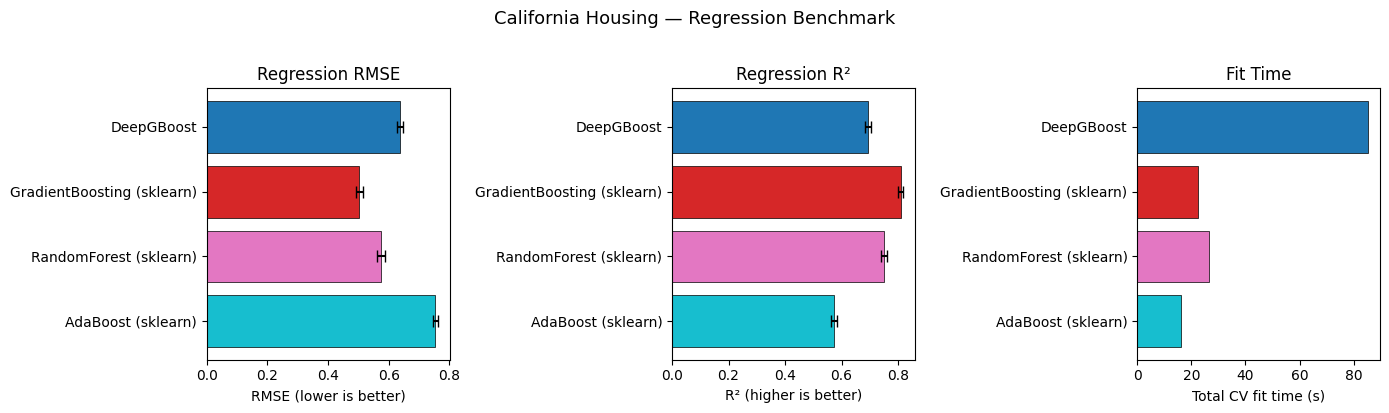

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
models = df_reg["Model"]
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

# RMSE
ax = axes[0]
bars = ax.barh(models, df_reg["RMSE (mean)"], xerr=df_reg["RMSE (std)"],
               color=colors, capsize=4, edgecolor="k", linewidth=0.5)
ax.set_xlabel("RMSE (lower is better)")
ax.set_title("Regression RMSE")
ax.invert_yaxis()

# R²
ax = axes[1]
ax.barh(models, df_reg["R2 (mean)"], xerr=df_reg["R2 (std)"],
        color=colors, capsize=4, edgecolor="k", linewidth=0.5)
ax.set_xlabel("R² (higher is better)")
ax.set_title("Regression R²")
ax.invert_yaxis()

# Fit time
ax = axes[2]
ax.barh(models, df_reg["Fit time (s)"],
        color=colors, edgecolor="k", linewidth=0.5)
ax.set_xlabel("Total CV fit time (s)")
ax.set_title("Fit Time")
ax.invert_yaxis()

plt.suptitle("California Housing — Regression Benchmark", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "regression_benchmark.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 2. Binary Classification — Breast Cancer

Metrics: **Accuracy** and **ROC-AUC** (higher is better).

In [7]:
bc = load_breast_cancer()
X_bin, y_bin = bc.data, bc.target
print(f"Breast Cancer: {X_bin.shape}  classes {np.bincount(y_bin)}")

cv_bin = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RNG)
scoring_bin = {"Accuracy": "accuracy", "ROC-AUC": "roc_auc"}

Breast Cancer: (569, 30)  classes [212 357]


In [8]:
binary_clfs = [
    ("DeepGBoost",
     DeepGBoostClassifier(n_trees=5, n_layers=10, max_depth=4,
                           learning_rate=0.15, random_state=RNG)),
    ("GradientBoosting (sklearn)",
     GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                 learning_rate=0.1, random_state=RNG)),
    ("RandomForest (sklearn)",
     RandomForestClassifier(n_estimators=100, max_depth=8, random_state=RNG)),
    ("AdaBoost (sklearn)",
     AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=RNG)),
]

if HAS_XGB:
    binary_clfs.append(
        ("XGBoost",
         XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                        use_label_encoder=False, eval_metric="logloss",
                        verbosity=0, random_state=RNG))
    )
if HAS_LGBM:
    binary_clfs.append(
        ("LightGBM",
         LGBMClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                         random_state=RNG, verbose=-1))
    )

bin_rows = []
for name, est in binary_clfs:
    print(f"  Running {name} ...", end="", flush=True)
    row = run_cv(name, est, X_bin, y_bin, cv=cv_bin, scoring=scoring_bin)
    bin_rows.append(row)
    print(f"  Acc={row['Accuracy (mean)']:.4f}  AUC={row['ROC-AUC (mean)']:.4f}")

df_bin = pd.DataFrame(bin_rows)
df_bin

  Running DeepGBoost ...  Acc=0.9350  AUC=nan
  Running GradientBoosting (sklearn) ...  Acc=0.9561  AUC=0.9905
  Running RandomForest (sklearn) ...  Acc=0.9561  AUC=0.9884
  Running AdaBoost (sklearn) ...  Acc=0.9561  AUC=0.9887


,Model,Fit time (s),Accuracy (mean),Accuracy (std),ROC-AUC (mean),ROC-AUC (std)
0,DeepGBoost,1.09,0.9350,0.0306,NaN,NaN
1,GradientBoosting (sklearn),2.69,0.9561,0.0184,0.9905,0.0055
2,RandomForest (sklearn),0.91,0.9561,0.0123,0.9884,0.0083
3,AdaBoost (sklearn),1.49,0.9561,0.0124,0.9887,0.0075


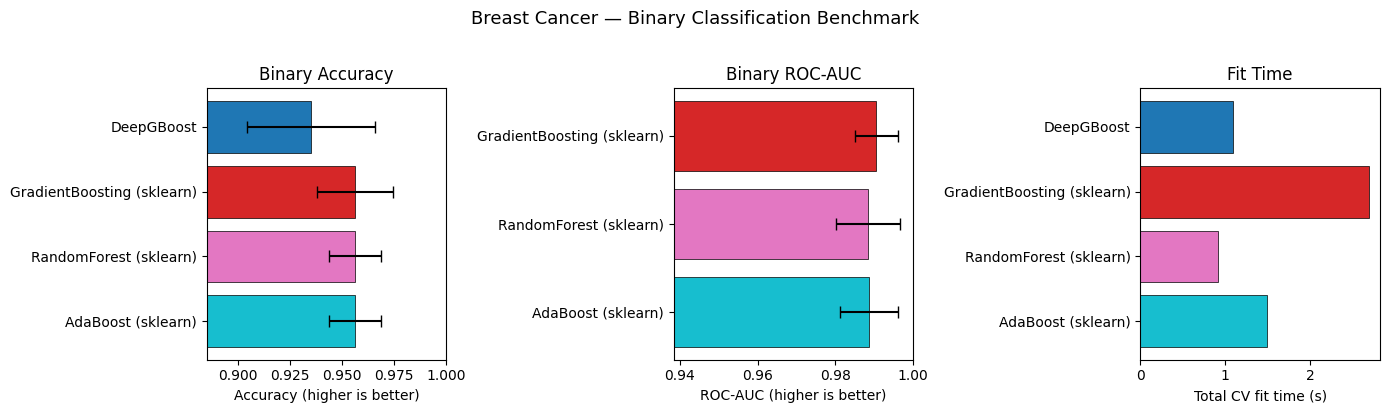

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
models = df_bin["Model"]
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for ax, metric in zip(axes[:2], ["Accuracy", "ROC-AUC"]):
    ax.barh(models, df_bin[f"{metric} (mean)"], xerr=df_bin[f"{metric} (std)"],
            color=colors, capsize=4, edgecolor="k", linewidth=0.5)
    ax.set_xlabel(f"{metric} (higher is better)")
    ax.set_title(f"Binary {metric}")
    ax.invert_yaxis()
    ax.set_xlim([max(0, df_bin[f"{metric} (mean)"].min() - 0.05), 1.0])

axes[2].barh(models, df_bin["Fit time (s)"],
             color=colors, edgecolor="k", linewidth=0.5)
axes[2].set_xlabel("Total CV fit time (s)")
axes[2].set_title("Fit Time")
axes[2].invert_yaxis()

plt.suptitle("Breast Cancer — Binary Classification Benchmark", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "binary_classification_benchmark.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 3. Multiclass Classification — Iris

Metrics: **Accuracy** and **macro ROC-AUC** (higher is better).

In [10]:
iris = load_iris()
X_mc, y_mc = iris.data, iris.target
print(f"Iris: {X_mc.shape}  classes {np.bincount(y_mc)}")

cv_mc = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RNG)
scoring_mc = {"Accuracy": "accuracy", "ROC-AUC": "roc_auc_ovr_weighted"}

Iris: (150, 4)  classes [50 50 50]


In [11]:
mc_clfs = [
    ("DeepGBoost",
     DeepGBoostClassifier(n_trees=5, n_layers=8, max_depth=3,
                           learning_rate=0.1, random_state=RNG)),
    ("GradientBoosting (sklearn)",
     GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                 learning_rate=0.1, random_state=RNG)),
    ("RandomForest (sklearn)",
     RandomForestClassifier(n_estimators=100, max_depth=6, random_state=RNG)),
    ("AdaBoost (sklearn)",
     AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=RNG)),
]

if HAS_XGB:
    mc_clfs.append(
        ("XGBoost",
         XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,
                        use_label_encoder=False, eval_metric="mlogloss",
                        verbosity=0, random_state=RNG))
    )
if HAS_LGBM:
    mc_clfs.append(
        ("LightGBM",
         LGBMClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,
                         random_state=RNG, verbose=-1))
    )

mc_rows = []
for name, est in mc_clfs:
    print(f"  Running {name} ...", end="", flush=True)
    row = run_cv(name, est, X_mc, y_mc, cv=cv_mc, scoring=scoring_mc)
    mc_rows.append(row)
    print(f"  Acc={row['Accuracy (mean)']:.4f}  AUC={row['ROC-AUC (mean)']:.4f}")

df_mc = pd.DataFrame(mc_rows)
df_mc

  Running DeepGBoost ...  Acc=0.9600  AUC=nan
  Running GradientBoosting (sklearn) ...  Acc=0.9533  AUC=0.9927
  Running RandomForest (sklearn) ...  Acc=0.9467  AUC=0.9940
  Running AdaBoost (sklearn) ...  Acc=0.9600  AUC=0.9923


,Model,Fit time (s),Accuracy (mean),Accuracy (std),ROC-AUC (mean),ROC-AUC (std)
0,DeepGBoost,0.67,0.9600,0.0389,NaN,NaN
1,GradientBoosting (sklearn),0.94,0.9533,0.0340,0.9927,0.0080
2,RandomForest (sklearn),0.61,0.9467,0.0267,0.9940,0.0080
3,AdaBoost (sklearn),0.76,0.9600,0.0389,0.9923,0.0066


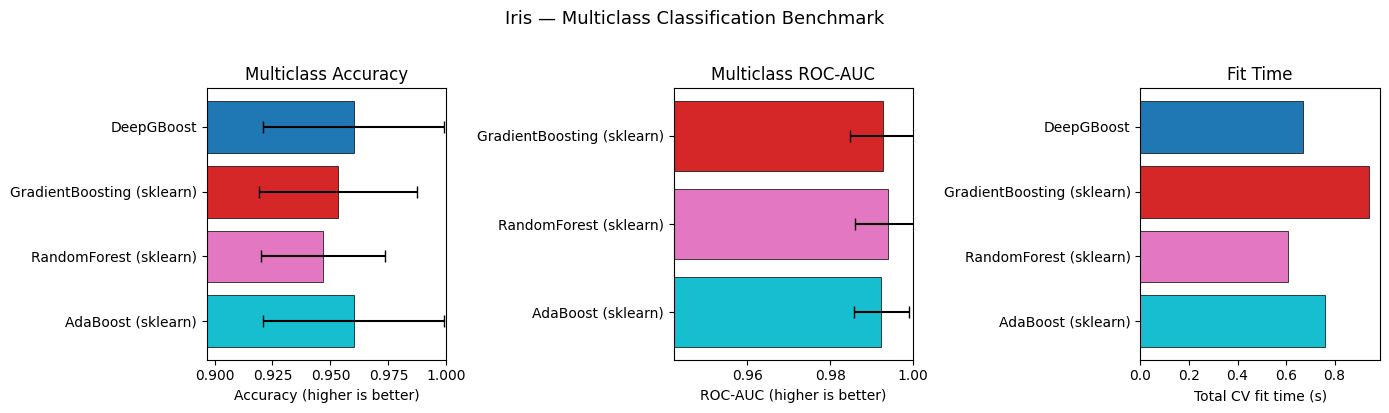

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
models = df_mc["Model"]
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for ax, metric in zip(axes[:2], ["Accuracy", "ROC-AUC"]):
    ax.barh(models, df_mc[f"{metric} (mean)"], xerr=df_mc[f"{metric} (std)"],
            color=colors, capsize=4, edgecolor="k", linewidth=0.5)
    ax.set_xlabel(f"{metric} (higher is better)")
    ax.set_title(f"Multiclass {metric}")
    ax.invert_yaxis()
    ax.set_xlim([max(0, df_mc[f"{metric} (mean)"].min() - 0.05), 1.0])

axes[2].barh(models, df_mc["Fit time (s)"],
             color=colors, edgecolor="k", linewidth=0.5)
axes[2].set_xlabel("Total CV fit time (s)")
axes[2].set_title("Fit Time")
axes[2].invert_yaxis()

plt.suptitle("Iris — Multiclass Classification Benchmark", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "multiclass_classification_benchmark.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 4. Save results to `results.md`

In [13]:
import platform, sklearn, deepgboost as dgb

optional_versions = []
if HAS_XGB:
    import xgboost; optional_versions.append(f"xgboost=={xgboost.__version__}")
if HAS_LGBM:
    import lightgbm; optional_versions.append(f"lightgbm=={lightgbm.__version__}")

env_lines = [
    f"- Python {platform.python_version()}",
    f"- deepgboost=={dgb.__version__}",
    f"- scikit-learn=={sklearn.__version__}",
    f"- numpy=={np.__version__}",
] + [f"- {v}" for v in optional_versions]

md = f"""# DeepGBoost Benchmark Results

All scores are {N_FOLDS}-fold cross-validation means ± std.

## Environment

{'chr(10)'.join(env_lines)}

---

## 1. Regression — California Housing

{df_to_markdown(df_reg)}

![Regression benchmark](regression_benchmark.png)

---

## 2. Binary Classification — Breast Cancer

{df_to_markdown(df_bin)}

![Binary classification benchmark](binary_classification_benchmark.png)

---

## 3. Multiclass Classification — Iris

{df_to_markdown(df_mc)}

![Multiclass classification benchmark](multiclass_classification_benchmark.png)
"""

out_path = RESULTS_DIR / "results.md"
out_path.write_text(md, encoding="utf-8")
print(f"Results saved to: {out_path.resolve()}")

Results saved to: /home/thinbaker/Workspace/DeepGBoost/benchmark/results.md


In [14]:
# Preview the markdown
print(out_path.read_text(encoding="utf-8"))

# DeepGBoost Benchmark Results

All scores are 5-fold cross-validation means ± std.

## Environment

- Python 3.13.5chr(10)- deepgboost==0.1.0chr(10)- scikit-learn==1.8.0chr(10)- numpy==2.4.4

---

## 1. Regression — California Housing

| Model | Fit time (s) | RMSE (mean) | RMSE (std) | R2 (mean) | R2 (std) |
| --- | --- | --- | --- | --- | --- |
| DeepGBoost | 85.45 | 0.6386 | 0.01 | 0.6935 | 0.0095 |
| GradientBoosting (sklearn) | 22.41 | 0.5036 | 0.0114 | 0.8094 | 0.0088 |
| RandomForest (sklearn) | 26.38 | 0.5753 | 0.013 | 0.7513 | 0.0109 |
| AdaBoost (sklearn) | 16.34 | 0.754 | 0.0089 | 0.5728 | 0.0116 |

![Regression benchmark](regression_benchmark.png)

---

## 2. Binary Classification — Breast Cancer

| Model | Fit time (s) | Accuracy (mean) | Accuracy (std) | ROC-AUC (mean) | ROC-AUC (std) |
| --- | --- | --- | --- | --- | --- |
| DeepGBoost | 1.09 | 0.935 | 0.0306 | nan | nan |
| GradientBoosting (sklearn) | 2.69 | 0.9561 | 0.0184 | 0.9905 | 0.0055 |
| RandomForest (sklearn)